# 8-Channel MTS example test
---

This notebook is based on Xilinx [RFSoC-MTS](https://github.com/Xilinx/RFSoC-MTS/blob/main/boards/ZCU208/notebooks/rfsocMTS.ipynb) and enabling all 8 ADCs and DACs.

This overlay provides one DAC player memory that is broadcast to multiple RF DAC tiles. All ADC tiles capture to internal memories.  ADC tile 225 channel 1 stores to the PL DRAM via DMA.  A simplified block diagram is presented below.

The following results were captured when looping back DAC 0 -> ADC 0, DAC 1 -> ADC 1, DAC 2 -> ADC 2, DAC 3 -> ADC 3, DAC 4 -> ADC 4, DAC 5 -> ADC 5, DAC 6 -> ADC 6, and DAC 7 -> ADC 7 (using SMA female-to-female SMA adapters and SMA DC Blocks).

### Preparation from a PYNQ 3.0.1 image:

1. Patch xrfdc to version 2.0 for enabling MTS following the [installation script](https://github.com/Xilinx/RFSoC-MTS/blob/main/install.sh).
2. Install `xrfclk` TICS files for testing frequency settings: 4.0 Gsps for DAC and ADC.
    ```
    sudo cp pynq_llrf/boards/CLK104/external_mo/*.txt* /usr/local/share/pynq-venv/lib/python3.10/site-packages/xrfclk/
    ```
3. Expect the following files in `/home/xilinx/jupyter_notebooks/RFSoC-MTS/pynq_llrf/mimo_mts`:
    * `ddr4.dtbo`: built by `pynq_llrf/boards/ZCU208/dts/Make` via device tree compiler
    * `mts_8ch_evr.bit` and `mts_8ch_evr.hwh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/RFSoC-MTS/pynq_llrf

/home/xilinx/jupyter_notebooks/RFSoC-MTS/pynq_llrf


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

from pynq import Clocks
from mimo_mts import MimoMtsOverlay

plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = "both"
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.size'] = 8

%load_ext autoreload
%autoreload 2

In [3]:
ol = MimoMtsOverlay("mts_8ch.bit", lmk_freq=499.63, lmx_freq=3997.11)

print(f'Overlay loaded :{ol.is_loaded()}')

Addr 0x147: val = 0xa; clkin = clkin0 (ext)


Overlay loaded :True


In [4]:
print(f'CPU:   {Clocks.cpu_mhz:10.3f} MHz')
print(f'FCLK0: {Clocks.fclk0_mhz:10.3f} MHz')

CPU:     1199.988 MHz
FCLK0:     99.999 MHz


In [5]:
from mimo_mts.utils.plot import plot_adc_wfm, plot_adc_psd

DAC_SR = 3997.11e6
ADC_SR = 3997.11e6

# Generate Waveforms for Loopback
 This overlay uses a single waveform memory that is broadcast to multiple DAC tiles.
### Prepare the DAC Memory
The cell below generates examples waveforms and has customizable paramters.  For example, one can adjust the center frequency, Fc, and re-generate a sinewave.

In [6]:
Fc = 250e6
n_samples = ol.dac_player.size
t_axis = np.arange(n_samples) / DAC_SR
amp =  (1 << 14) - 1
DAC_sinewave = amp * np.sin(2 * np.pi * Fc * t_axis)

In [7]:
ol.dac_player[:] = np.int16(DAC_sinewave)

## Capture DAC Waveform to Internal Memory

The DAC waveform is saved to an internal memory for verification purposes.

XXX: Observed phase of `dac_capture` is not reproducible!

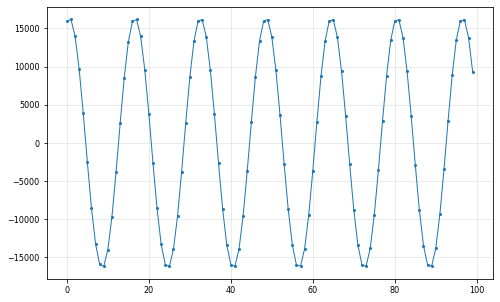

In [8]:
ol.trigger_capture()
plt.plot(ol.dac_capture[:100], marker='o', linewidth=1, markersize=2);

In [9]:
darray_i = np.empty((ol.n_adcs, len(ol.adc_i_bufs[0])), dtype=np.int16)
darray_q = np.empty((ol.n_adcs, len(ol.adc_q_bufs[0])), dtype=np.int16)

ol.set_adc_mixer_dco(phase=0)
ol.capture_adc_iq_buf(darray_i, darray_q);

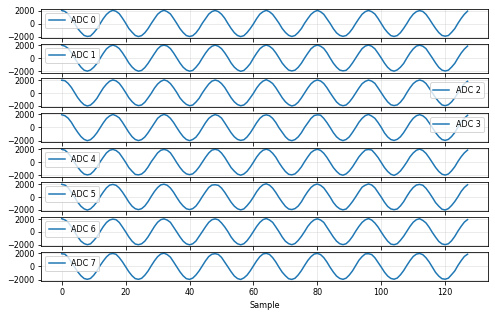

In [10]:
fig, axes = plt.subplots(ol.n_adcs, 1, sharex=True)
for ch, ax in enumerate(axes):
    ax.plot(darray_i[ch, :128], label=f'ADC {ch}')
    ax.legend()
    ax.grid(True)
axes[-1].set_xlabel('Sample');

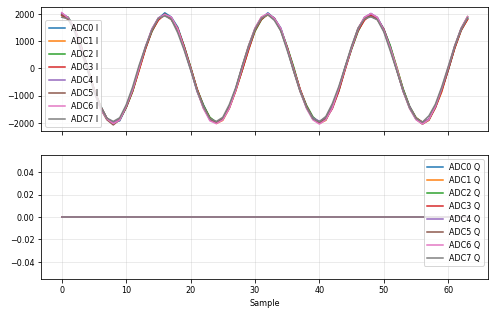

In [11]:
fig, axes = plt.subplots(2, 1, sharex=True)
for ch, (i, q) in enumerate(zip(darray_i, darray_q)):
    axes[0].plot(i[:64], label=f'ADC{ch} I')
    axes[1].plot(q[:64], label=f'ADC{ch} Q')
    axes[0].legend()
    axes[1].legend()
axes[-1].set_xlabel('Sample');

### Change mixer phase to 90 deg and check I/Q waveforms

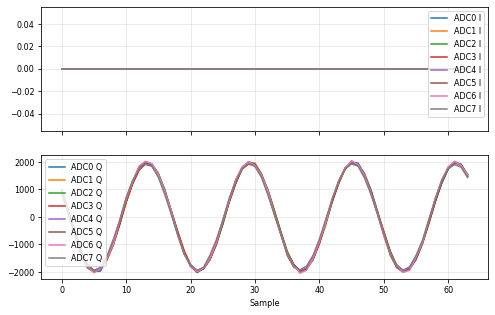

In [12]:
ol.set_adc_mixer_dco(phase=90)
ol.capture_adc_iq_buf(darray_i, darray_q);

fig, axes = plt.subplots(2, 1, sharex=True)
for ch, (i, q) in enumerate(zip(darray_i, darray_q)):
    axes[0].plot(i[:64], label=f'ADC{ch} I')
    axes[1].plot(q[:64], label=f'ADC{ch} Q')
    axes[0].legend()
    axes[1].legend()
axes[-1].set_xlabel('Sample');

### Verify Alignment Stability

In [13]:
n_samples = 1024
for i in range(3):
    ol.capture_adc_iq_buf(darray_i, darray_q);
    x = darray_q[0, :n_samples].astype(np.float32)
    y = darray_q[3, :n_samples].astype(np.float32)
    x_corr = np.correlate(x, y, mode='full')
    lags = np.arange(-n_samples+1, n_samples)
    delay = lags[np.argmax(x_corr)]
    print(f'Iteration {i} : Cross-correlation delay = {delay} samples')
    assert delay == 0, 'Cross-correlation delay is not zero'

Iteration 0 : Cross-correlation delay = 0 samples
Iteration 1 : Cross-correlation delay = 0 samples
Iteration 2 : Cross-correlation delay = 0 samples


### Latency Incurred Due To Alignment

Observed DAC / ADC Tile latencies:
* 112, 96
* 120, 88

In [14]:
for i in range(4):
    print(f"DAC Tile {i} Latency: {ol.xrfdc.mts_dac_config.Latency[i]:3d}, Offset: {ol.xrfdc.mts_dac_config.Offset[i]}")
    print(f"ADC Tile {i} Latency: {ol.xrfdc.mts_adc_config.Latency[i]:3d}, Offset: {ol.xrfdc.mts_adc_config.Offset[i]}")

DAC Tile 0 Latency: 120, Offset: 0
ADC Tile 0 Latency:  88, Offset: 0
DAC Tile 1 Latency: 120, Offset: 0
ADC Tile 1 Latency:  88, Offset: 0
DAC Tile 2 Latency: 120, Offset: 0
ADC Tile 2 Latency:  88, Offset: 0
DAC Tile 3 Latency: 120, Offset: 0
ADC Tile 3 Latency:  88, Offset: 0


### Set DAC baseband waveform as DC, reset mixer

In [15]:
n_samples = ol.dac_player.size
ol.dac_player[:] = np.ones(n_samples, dtype=np.int16) * 32767
ol.set_dac_mixer_dco(0)
ol.set_adc_mixer_dco(0)

### Change DAC mixer setting with NCO to 125 MHz

In [16]:
ol.set_dac_mixer_dco(125)

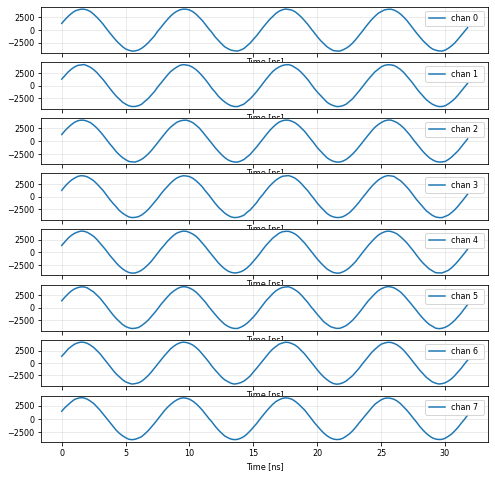

In [17]:
ol.capture_adc_iq_buf(darray_i, darray_q);
plot_adc_wfm(darray_i[:, :128], height=1, fs=ADC_SR)

###  Change DAC mixer setting with NCO to 500 MHz

In [18]:
ol.set_dac_mixer_dco(500)

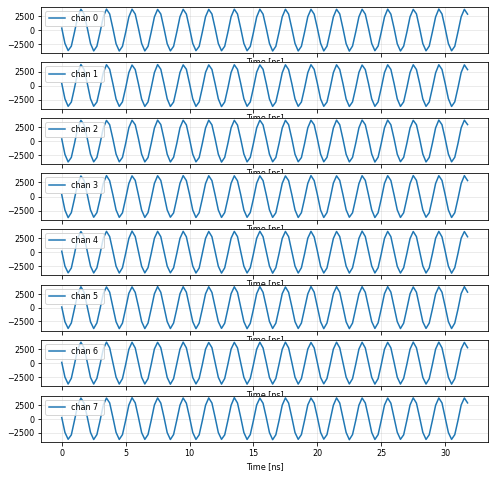

In [19]:
ol.capture_adc_iq_buf(darray_i, darray_q);
plot_adc_wfm(darray_i[:, :128])

In [ ]:
plot_adc_psd(darray_i, fs=ADC_SR)

###  Test ADC mixer - Set ADC DCO to 300 MHz

expect $300 \pm 500 = 800, -200$ MHz output frequency

In [24]:
ol.set_adc_mixer_dco(300)

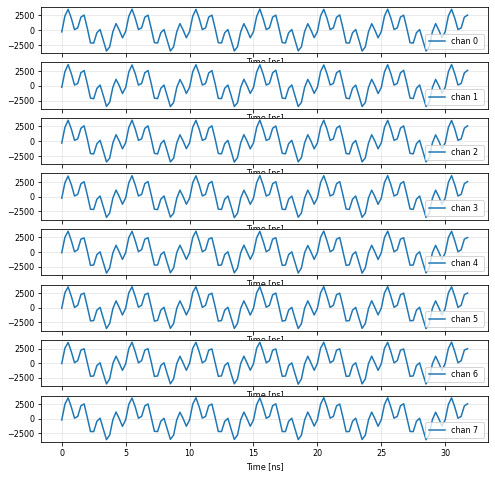

In [ ]:
ol.capture_adc_iq_buf(darray_i, darray_q);
iq_bufs = darray_i + 1j * darray_q
plot_adc_wfm(iq_bufs.real[:, :128], fs=ADC_SR)

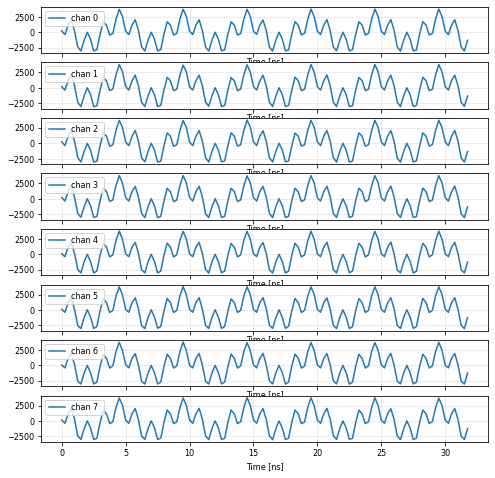

In [ ]:
plot_adc_wfm(iq_bufs.imag[:, :128], fs=ADC_SR)

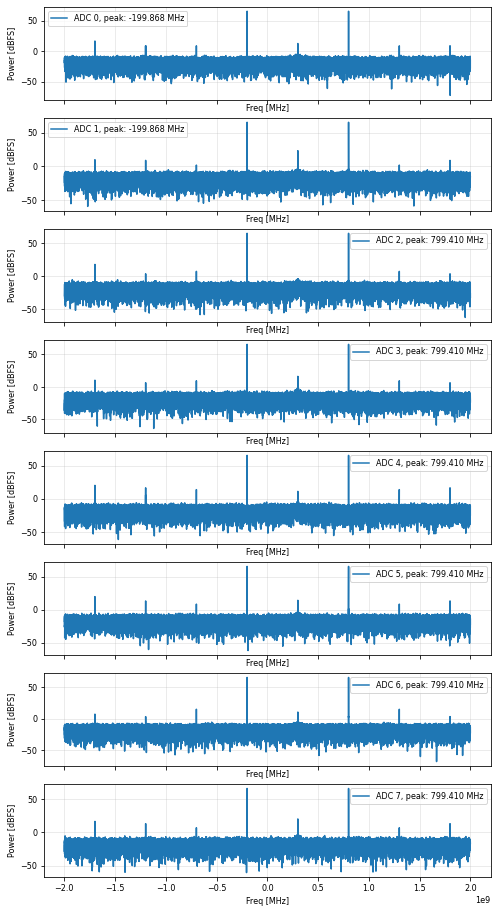

In [ ]:
plot_adc_psd(iq_bufs, onsided=False, fs=ADC_SR)